# xs-signal-research: results

Everything here reads `results/*.json` and the run parquets written by `python -m xsig all`; re-run the pipeline and re-execute to refresh.

In [2]:
import json, os, sys
import numpy as np, pandas as pd
sys.path.insert(0, os.path.abspath('..'))
from IPython.display import Image, display
from xsig import metrics as M
R = {n: json.load(open(f'../results/{n}.json')) for n in ('signal', 'validate', 'ablate', 'neutralise', 'costs', 'transfer') if os.path.exists(f'../results/{n}.json')}
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)

## 1. The signal out of sample

Daily Spearman IC of the walk-forward blend against the 5-day demeaned forward return, with a Newey–West t and a moving-block-bootstrap band; by year; IC decay; a model per horizon.

{'ic_mean': 0.0177, 'ic_sd': 0.2097, 't_nw': 3.0697, 'ic_lo': 0.0058, 'ic_hi': 0.0299, 'n_days': 4197, 'share_positive': 0.5289, 'ir_annual': 0.5984}


,ic_mean,ic_sd,n_days,ic_train
2010,0.0135,0.1418,252.0,0.0819
2011,-0.0026,0.2256,252.0,0.0649
2012,0.0100,0.1503,250.0,0.0609
2013,0.0264,0.1139,252.0,0.0556
2014,0.0337,0.1822,252.0,0.0435
2015,0.0078,0.1844,252.0,0.0395
2016,0.0216,0.2022,252.0,0.0412
2017,0.0066,0.1656,251.0,0.0406
2018,0.0302,0.1920,251.0,0.0401
2019,0.0380,0.1983,252.0,0.0363


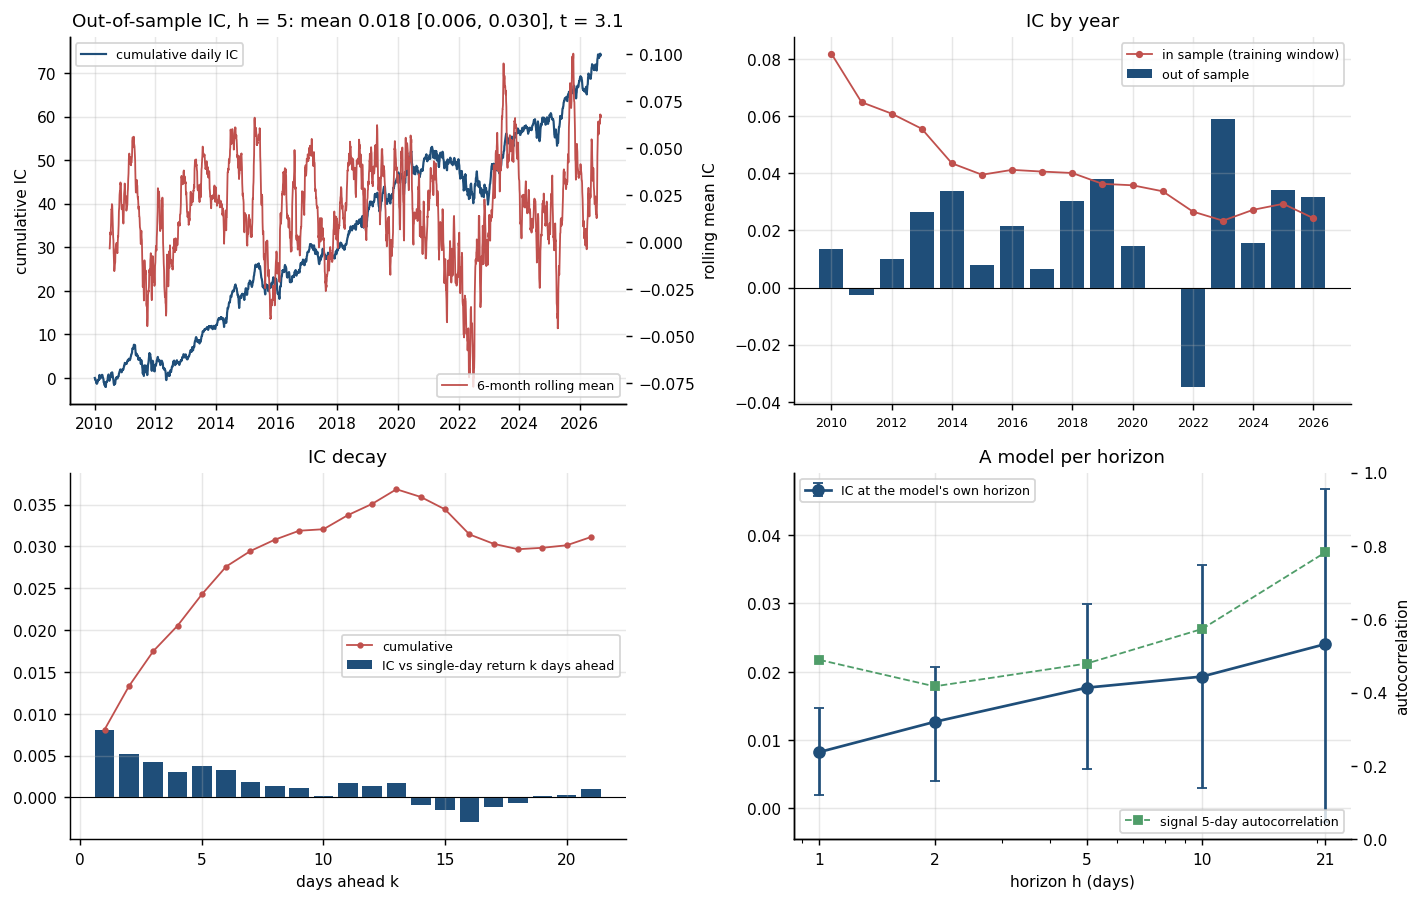

In [4]:
S = R['signal']
print({k: round(v, 4) if isinstance(v, float) else v for k, v in S['ic'].items()})
by = pd.DataFrame(S['by_year']).T; by['ic_train'] = pd.Series(S['ic_train_by_year']); display(by.round(4))
display(Image('../results/figures/signal.png'))

In [5]:
hz = S['horizons']
display(pd.DataFrame({h: {'ic': v['own']['ic_mean'], 'lo': v['own']['ic_lo'], 'hi': v['own']['ic_hi'], 't': v['own']['t_nw'], 'ac_5': v['autocorrelation']['ac_5']} for h, v in hz.items()}).T.round(4))

,ic,lo,hi,t,ac_5
1,0.0082,0.0019,0.0147,2.5256,0.4892
2,0.0127,0.0041,0.0207,3.1302,0.4168
5,0.0177,0.0058,0.0299,3.0697,0.4791
10,0.0193,0.0029,0.0357,2.4840,0.5733
21,0.0241,-0.0021,0.0467,2.0712,0.7824


## 2. Honest validation

The same learner under five schemes.  Shuffled K-fold sees the test day's neighbours in training; purged and embargoed K-fold does not, and it lands where walk-forward lands.

h = 5
h = 21


,ic_mean,ic_sd,n_days
in_sample,0.0264,0.2509,4197.0
kfold_shuffled,0.0232,0.2428,4197.0
kfold_blocked,0.0201,0.2469,4197.0
purged,0.0220,0.2426,4197.0
walk_forward,0.0177,0.2097,4197.0


,ic_mean,ic_sd,n_days
in_sample,0.0465,0.2460,4181.0
kfold_shuffled,0.0438,0.2398,4181.0
kfold_blocked,0.0359,0.2402,4181.0
purged,0.0359,0.2401,4181.0
walk_forward,0.0241,0.2111,4181.0


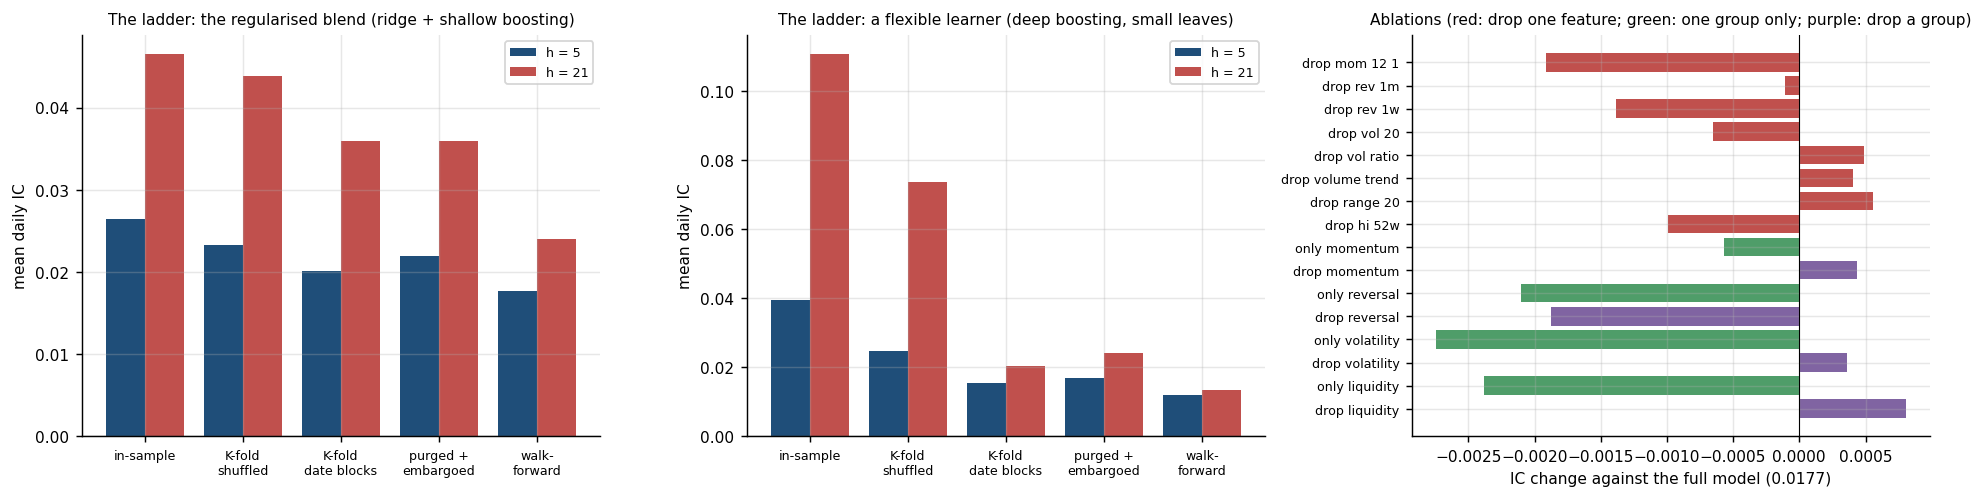

In [7]:
for h, lad in R['validate']['ladder'].items():
    print('h =', h); display(pd.DataFrame(lad).T.round(4))
display(Image('../results/figures/validation.png'))

## 3. Ablations

Drop one feature, keep one group, drop one group; the change in IC against the full model with a Newey–West t on the daily difference; each feature alone through ridge.

In [9]:
A = R['ablate']
display(pd.DataFrame(A['variants']).T[['ic_mean', 't_nw', 'decile_spread', 'delta_vs_full', 'delta_t']].round(4))
display(pd.DataFrame(A['single_feature']).T[['ic_mean', 't_nw']].round(4))

,ic_mean,t_nw,decile_spread,delta_vs_full,delta_t
full,0.0177,3.0697,0.0034,NaN,NaN
drop_mom_12_1,0.0158,2.7002,0.0032,-0.0019,-2.0713
drop_rev_1m,0.0176,3.0290,0.0031,-0.0001,-0.2481
drop_rev_1w,0.0163,2.5711,0.0035,-0.0014,-0.5947
drop_vol_20,0.0170,2.9093,0.0031,-0.0007,-0.9198
drop_vol_ratio,0.0182,3.1456,0.0033,0.0005,0.8112
drop_volume_trend,0.0181,3.1037,0.0032,0.0004,0.9933
drop_range_20,0.0182,3.1814,0.0032,0.0006,0.6237
drop_hi_52w,0.0167,2.9381,0.0030,-0.0010,-0.6636
only_momentum,0.0171,2.7395,0.0032,-0.0006,-0.1934


,ic_mean,t_nw
mom_12_1,-0.0057,-0.8339
rev_1m,0.0116,2.1955
rev_1w,0.0159,3.3877
vol_20,0.0147,2.1064
vol_ratio,-0.0021,-0.5537
volume_trend,-0.0057,-1.8671
range_20,0.0161,2.2015
hi_52w,0.0085,1.2806


## 4. Neutralisation against the risk model

Beta, size, sector, then momentum and volatility (which are also the signal's inputs); Fama–MacBeth factor premia and the attribution of the gross rank book.

exposure correlations {'beta': 0.332, 'size': 0.091, 'mom_12_1': -0.035, 'vol_20': 0.431}
attribution {'alpha': 0.0005, 'alpha_t': 2.1213, 'loadings': {'beta': 0.2513735471953871, 'size': 0.3981927543257684, 'mom_12_1': 0.018675782817945477, 'vol_20': 0.7293915122020698}, 'r2': 0.5565, 'n': 840}


,ic,lo,hi,t,decile_bp
raw,0.0177,0.0058,0.0299,3.0697,33.7319
sector-neutral,0.0123,0.0038,0.0206,2.9823,31.1402
"beta, size and sector neutral",0.0086,0.0024,0.0147,2.7845,23.9071
plus momentum and volatility neutral,0.0085,0.0027,0.0139,2.9871,19.0208


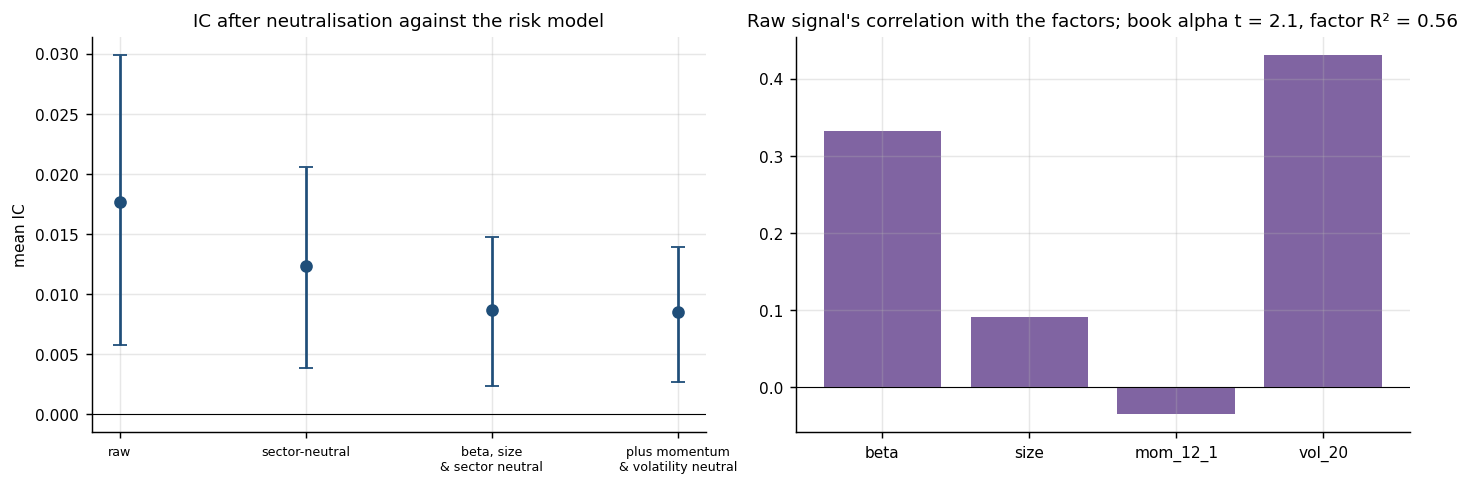

In [11]:
N = R['neutralise']
display(pd.DataFrame({v['label']: {'ic': v['ic']['ic_mean'], 'lo': v['ic']['ic_lo'], 'hi': v['ic']['ic_hi'], 't': v['ic']['t_nw'], 'decile_bp': v['decile_spread'] * 1e4} for v in N['signals'].values()}).T.round(4))
print('exposure correlations', {k: round(v, 3) for k, v in N['exposure_corr'].items()})
print('attribution', {k: (round(v, 4) if isinstance(v, float) else v) for k, v in N['attribution'].items()})
display(Image('../results/figures/neutral.png'))

## 5. Costs and capacity

The algo-wheel cost model on the rank book at $1bn; the capacity curve; each horizon in its own book; the net IC; the deflated Sharpe.

net IC {'ic_mean': 0.0009, 'ic_sd': 0.2099, 't_nw': 0.1496, 'ic_lo': -0.0111, 'ic_hi': 0.013, 'n_days': 4197, 'share_positive': 0.4906, 'ir_annual': 0.0291}
breakeven capital 3553360668.274148
deflated Sharpe {'sr': 0.033548245436984855, 'sr0': 0.06727199649330713, 'dsr': 0.16138527499604044, 'n_trials': 41, 'skew': 0.7772492810735556, 'kurtosis': 8.248948556018782}


,gross_ann,net_ann,cost_ann,sharpe_gross,sharpe_net,turnover,avg_cost_bp,max_dd_net
routed,0.059642,0.0265,0.033142,0.737757,0.325507,0.474453,6.737711,-0.149548
observed,0.059642,0.01666,0.042982,0.737757,0.203011,0.474453,8.696961,-0.179609


,gross_ann,net_ann,cost_ann,sharpe_net,turnover,avg_cost_bp,max_pct_adv,net_ic
100000000.0,0.0596,0.0463,0.0133,0.5723,0.4745,2.7208,0.0533,0.0108
250000000.0,0.0596,0.0410,0.0186,0.5060,0.4745,3.8004,0.1333,0.0081
500000000.0,0.0596,0.0350,0.0246,0.4312,0.4745,5.0171,0.2666,0.0051
1000000000.0,0.0596,0.0265,0.0331,0.3255,0.4745,6.7377,0.5333,0.0009
2500000000.0,0.0596,0.0096,0.0500,0.1157,0.4745,10.1517,1.3332,-0.0075
5000000000.0,0.0596,-0.0094,0.0690,-0.1206,0.4745,13.9991,2.6664,-0.0169
10000000000.0,0.0596,-0.0362,0.0959,-0.4543,0.4745,19.4402,5.3327,-0.0302
25000000000.0,0.0596,-0.0896,0.1492,-1.1124,0.4745,30.2362,13.3318,-0.0557


,gross_ann,net_ann,sharpe_net,turnover,avg_cost_bp
1,0.062087,0.003897,0.047137,0.217105,5.167876
2,0.065784,0.016931,0.211632,0.320571,5.900821
5,0.059642,0.0265,0.325507,0.474453,6.737711
10,0.051546,0.035618,0.483828,0.445423,6.779251
21,0.052891,0.046639,0.568128,0.3876,6.439111


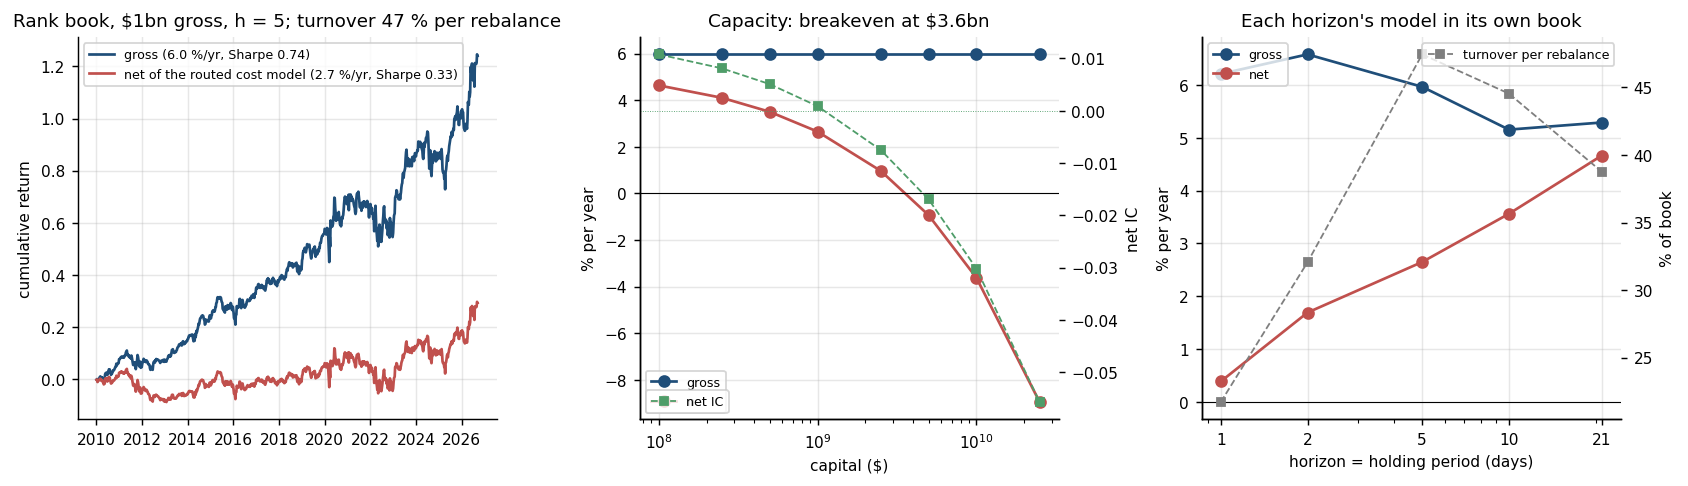

In [13]:
K = R['costs']
display(pd.DataFrame(K['models']).T[['gross_ann', 'net_ann', 'cost_ann', 'sharpe_gross', 'sharpe_net', 'turnover', 'avg_cost_bp', 'max_dd_net']].round(4))
print('net IC', {k: round(v, 4) for k, v in K['models']['routed']['net_ic'].items()})
cap = pd.DataFrame(K['capacity']).T; display(cap.round(4)); print('breakeven capital', K['breakeven_capital'])
display(pd.DataFrame(K['by_horizon']).T[['gross_ann', 'net_ann', 'sharpe_net', 'turnover', 'avg_cost_bp']].round(4))
print('deflated Sharpe', K['deflated'])
display(Image('../results/figures/costs.png'))

## 6. New products: ETFs and futures

The equity-fitted models of each year applied unchanged to the ETF and futures frames, the same learner refitted within each universe, and each feature's univariate IC by universe.

,universe,model,n,ic,lo,hi,t,net_ann,sharpe_net
0,equity,own_model,156,0.0177,0.0058,0.0299,3.0697,0.0265,0.3255
1,etf,equity_model,92,0.0218,0.0054,0.0387,2.6953,-0.0315,-0.3922
2,etf,own_model,92,0.0256,0.0108,0.0409,3.4423,-0.0486,-0.6941
3,futures,equity_model,34,0.0238,0.0073,0.0392,3.1453,0.0628,0.6116
4,futures,own_model,34,0.0098,-0.0044,0.0254,1.3645,0.0340,0.3419


,equity,etf,futures
mom_12_1,0.0187,0.0392,0.0230
rev_1m,-0.0116,-0.0051,-0.0115
rev_1w,-0.0159,-0.0138,-0.0101
vol_20,0.0147,0.0292,0.0202
vol_ratio,0.0005,-0.0017,-0.0017
volume_trend,-0.0018,0.0034,0.0090
range_20,0.0161,0.0374,0.0262
hi_52w,-0.0085,-0.0035,-0.0090


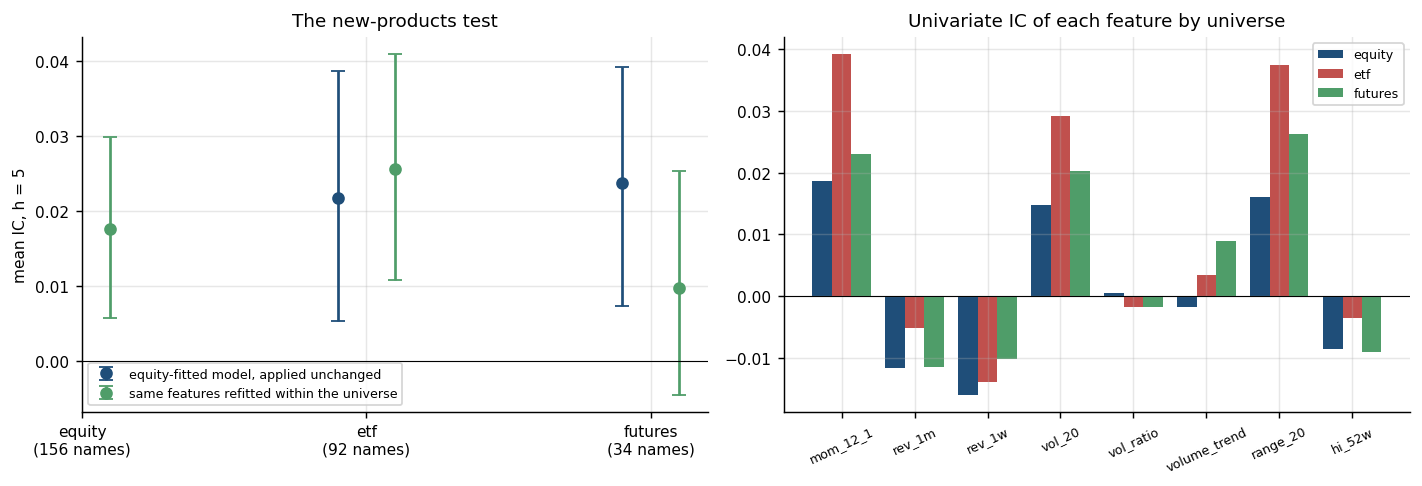

In [15]:
T = R['transfer']
rows = []
for u, r in T.items():
    if not isinstance(r, dict) or 'n_symbols' not in r: continue
    for key in ('equity_model', 'own_model'):
        if key in r and 'ic' in r[key]:
            ic = r[key]['ic']; b = r[key].get('book', {})
            rows.append({'universe': u, 'model': key, 'n': r['n_symbols'], 'ic': ic['ic_mean'], 'lo': ic.get('ic_lo'), 'hi': ic.get('ic_hi'), 't': ic['t_nw'], 'net_ann': b.get('net_ann'), 'sharpe_net': b.get('sharpe_net')})
display(pd.DataFrame(rows).round(4))
display(pd.DataFrame({u: {f: r['univariate'][f]['ic'] for f in r['univariate']} for u, r in T.items() if isinstance(r, dict) and 'univariate' in r}).round(4))
display(Image('../results/figures/transfer.png'))

## 7. SQL over the store

DuckDB views over the committed bars, the feature frames and the run parquets.

In [17]:
from xsig.data import store
con = store()
display(con.execute("SELECT symbol, COUNT(*) AS days, MIN(date) AS first, MAX(date) AS last, ROUND(AVG(volume * close) / 1e6) AS adv_musd FROM equity GROUP BY symbol ORDER BY adv_musd DESC LIMIT 10").df())
display(con.execute("SELECT EXTRACT(year FROM date) AS year, ROUND(AVG(z * target_5) * 1e4, 2) AS mean_z_times_target_bp, COUNT(*) AS n FROM pred_equity GROUP BY 1 ORDER BY 1").df())

,symbol,days,first,last,adv_musd
0,TSLA,4080,2010-06-29,2026-09-17,10731.0
1,AAPL,5031,2006-09-18,2026-09-17,8019.0
2,NVDA,5031,2006-09-18,2026-09-17,7090.0
3,META,3603,2012-05-18,2026-09-17,4893.0
4,AMZN,5031,2006-09-18,2026-09-17,4877.0
5,MSFT,5031,2006-09-18,2026-09-17,4277.0
6,GOOGL,5031,2006-09-18,2026-09-17,2946.0
7,AMD,5031,2006-09-18,2026-09-17,2727.0
8,MU,5031,2006-09-18,2026-09-17,1980.0
9,BAC,5031,2006-09-18,2026-09-17,1836.0


,year,mean_z_times_target_bp,n
0,2010,7.42,32581
1,2011,-3.46,33800
2,2012,0.90,33903
3,2013,12.74,35204
4,2014,11.51,36362
5,2015,4.20,36456
6,2016,13.47,36922
7,2017,6.51,37137
8,2018,6.25,37359
9,2019,14.15,37538
